# WSD Project Ruben Harutyunyan

# Autocallable note on Expedia: Monte Carlo pricing and risk

## The product

A structured note is a debt security issued by a bank. The investor lends the bank money, and the bank pays it back according to a formula linked to an underlying asset, in this case the share price of Expedia (EXPE). The note in this project is a 3-year autocallable of the Athena type, priced on 24 September 2026, when Expedia closed at $S_0 = 261.75$. The investor pays 100 at the start and receives exactly one payment, on the date the note ends. Which payment that is depends on two barriers, both set relative to $S_0$.

### Autocall barrier (100% of $S_0$)

At the end of years 1 and 2, the share price is compared with $S_0$. If it is at or above $S_0$, the note is "called" and the investor receives the 100 plus a coupon of 30 for every year that has passed. The note then ends and nothing more is paid. If the price is below $S_0$, the note simply continues to the next date. The coupons are not paid each year. They accumulate and are paid in one go when the note ends.

### Knock-in barrier (60% of $S_0$)

This barrier only matters if the note reaches year 3 without being called, and it is checked only once, on the final date. A fall below 60% in year 1 or 2 therefore has no affect if the price recovers by the end. If the final price is between 60% and 100% of $S_0$, the investor gets the 100 back but no coupon. This is called conditional capital protection: the stock can fall by up to 40% without the investor losing any capital. Below 60% the protection is gone and the investor receives $100 \cdot S_3/S_0$, so they carry the full loss of the stock.

| Date | Condition | Investor receives |
|---|---|---|
| Year 1 | $S_1 \geq S_0$ | 130, the note ends |
| Year 2 | $S_2 \geq S_0$ | 160, the note ends |
| Year 3 | $S_3 \geq S_0$ | 190 |
| Year 3 (only)| $0.6\,S_0 \leq S_3 < S_0$ | 100 |
| Year 3 (only)| $S_3 < 0.6\,S_0$ | $100 \cdot S_3 / S_0$ |

## Structure of the product

The note is easier to understand if we split it into three simpler parts.

1. A safe part that gives the investor the 100 back at the end (a zero-coupon bond).
2. Fixed coupons. On each check date, the investor receives a fixed amount of 30, 60 or 90 if Expedia is at or above its starting price, and nothing if it is below. 
3. A promise to cover large losses. If Expedia ends below 60% of its starting price, the investor takes the full fall of the stock. In other words, the investor has agreed to pay the bank if the stock crashes, which is the same as selling the bank insurance (a put option that only becomes active below 60%). Below the barrier, the payment can be written as
$$100 \cdot \frac{S_3}{S_0} = 100 - \frac{100}{S_0}\,(S_0 - S_3),$$
where 100 is the safe part and the second term is the fall of the stock, scaled to an investment of 100.

As already mentioned above the as soon as a coupon is paid, the note ends, the investor gets their money back early, and the promise to cover losses disappears. So whether the investor is still exposed to a crash at year 3 depends on what the stock did in years 1 and 2. Because the result depends on the whole path of the stock and not only on its final price, there is no simple formula for the price, and I use Monte Carlo simulation instead.

So basically the investor gives up any gains in the stock beyond the coupons and agrees to carry the risk of a large fall. The 30% yearly coupon is what the bank pays the investor for carrying that risk. Expedia's price moves a lot (a volatility of around 51% which I derive later), so a large fall is quite likely, and the bank has to pay a high coupon for the investor to be interested in holding the product.

The price is calculated as if the stock grew on average at the risk-free interest rate (the risk-neutral measure $Q$), which is the standard way to price such products. The risk for the investor is calculated with the stock's expected real-world growth $\mu$ (the real-world measure $P$).

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

## Market data

In this part I derive the market prices/data of the underlying from Yahoo. Daily closing prices of Expedia from 24 September 2021 to 24 September 2026. The prices are stored in `EXPE.csv` next to the notebook, so it runs without an internet connection. The download only runs if the file is missing.

In [12]:
# Download the Expedia (EXPE) prices only if the CSV is not there yet
if not os.path.exists("EXPE.csv"):
    data = yf.Ticker("EXPE").history(start="2021-09-24", end="2026-09-25") # it ends on 2026-09-24
    data.index = data.index.tz_localize(None) # remove the time zone that Yahoo attaches to the dates so now these are pure dates
    data[["Close"]].to_csv("EXPE.csv", index_label="Date") # keep only the prices when the market is closed 
    # the file looks like  date, price ...


# Daily closing prices
data = pd.read_csv("EXPE.csv", parse_dates=["Date"], index_col="Date") # we create a table from the csv file and swith Date column from text into real dates
prices = data["Close"]

Quick check that the last row is the pricing date (24 September 2026).

In [13]:
data.tail()

,Close
Date,
2026-09-18,279.350006
2026-09-21,281.019989
2026-09-22,280.700012
2026-09-23,259.040009
2026-09-24,261.750000


## Parameters

In this part I derive the drift and the volatility of the underlying.

Under GBM, daily log-returns are normal with mean $(\mu - \tfrac{1}{2}\sigma^2)\,dt$ and variance $\sigma^2 dt$, so both parameters can be read off the last year of returns.

The volatility is estimated precisely. Its standard error is about $\sigma/\sqrt{2(n-1)}$ (taken from the internet). The drift is different because of the volatility, the estimate of the historical estimate tells us very little. For that reason I assume $\mu = r + 5\%$ (an equity risk premium) and only use the historical $\mu$ as a comparison in the risk section.

$r$ is the 3-year US Treasury yield (FRED, series DGS3, 22 September 2026), matching the maturity of the note, and $q$ is Expedia's dividend yield.

In [14]:
previou_day_price = prices.shift(1) # moves the prices down by one raw, now on each day we know the closing price of the previous day as well
# Daily log-returns
log_ret = np.log(prices / previou_day_price).dropna()

# Keep only the last year of returns
last_year = log_ret[log_ret.index > log_ret.index[-1] - pd.DateOffset(years=1)] # we only keep the last year
n_obs = len(last_year)

# Historical volatility (annualised) and its standard error
sig = last_year.std() * np.sqrt(n_obs)
sig_se = sig / np.sqrt(2 * (n_obs - 1)) 

# Historical drift (annualised) and its standard error
mu_hist = last_year.mean() * n_obs + 0.5 * sig**2
mu_hist_se = sig 

# Market parameters
S0 = prices.iloc[-1] # price on the pricing date (close of 24 Sep 2026)
r = 0.0481 # 3-year US Treasury yield, 22 Sep 2026 
q = 0.73 / 100 # dividend yield = annual dividend 0.73%
mu = r + 0.05 # assumption: risk-free rate + 5% equity risk premium

print("S0:", S0)
print("sigma:", sig, "+/-", sig_se)
print("mu (historical):", mu_hist, "+/-", mu_hist_se)
print("mu (assumed):", mu)

S0: 261.75
sigma: 0.5068476310462622 +/- 0.0226669151450835
mu (historical): 0.31951882012241917 +/- 0.5068476310462622
mu (assumed): 0.09809999999999999


## Simulation under Q

For pricing, the stock follows GBM under $Q$ with drift $r - q$:
$$S_{t+1} = S_t \exp\left(\left(r - q - \tfrac{1}{2}\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t}\,Z\right), \qquad Z \sim N(0,1).$$
The payoff only looks at $t = 1, 2, 3$ and this formula is exact for any step size, so three steps per path are enough. I simulate 1,000,000 paths with a fixed seed so the results can be reproduced.

In [15]:
N = 1000000
dt = 1 # one year between observation dates

rng = np.random.default_rng(42) # fixed seed 
Z = rng.standard_normal((N, 3)) # one normal per path per date (t = 1, 2, 3)

# Yearly log-returns under Q wth the drift is r - q
log_steps_Q = (r - q - 0.5*sig**2)*dt + sig*np.sqrt(dt)*Z

# Stock price at t = 1, 2, 3 for every path, shape (N, 3)
S_Q = S0*np.exp(np.cumsum(log_steps_Q, axis=1))

## Payoff and price

Each path ends in exactly one of three groups: called at year 1, called at year 2, or still alive at year 3. Every cash flow is discounted from the date it is paid, and the price is the average over all paths:
$$\text{Price} = E_Q\left[\sum_i e^{-r t_i}\, CF_i\right].$$
With a 30% coupon the fair value comes out slightly below 100. The difference is roughly the issuer's margin.

In [16]:
notional = 100
c = 0.30 # coupon per year
AC = 1.0 * S0 # autocall barrier (100% of S0)
KI = 0.6 * S0 # knock-in barrier (60% of S0)

S1_Q = S_Q[:, 0]
S2_Q = S_Q[:, 1]
S3_Q = S_Q[:, 2]

# Which paths redeem at t = 1, at t = 2, or survive to t = 3
called_1_Q = S1_Q >= AC
called_2_Q = (~called_1_Q) & (S2_Q >= AC)
alive_3_Q = (~called_1_Q) & (~called_2_Q)

# Payoff at maturity (only used for the paths that survive to t = 3)
payoff_3_Q = np.where(S3_Q >= AC, notional*(1 + 3*c), np.where(S3_Q >= KI, notional, notional*S3_Q/S0))

# Each cash flow is discounted from the date it is paid
PV_Q = (called_1_Q * np.exp(-r*1) * notional*(1 + c) + called_2_Q * np.exp(-r*2) * notional*(1 + 2*c) + alive_3_Q * np.exp(-r*3) * payoff_3_Q)

price = np.mean(PV_Q)

In [17]:
price

96.03338135064273

## Conclusion on the pricing

This is the main part of the project. Using the Black-Scholes model for the stock and Monte Carlo simulation, we compute the price of the note. The price comes out at about 96, slightly below the 100 the investor pays to buy it. The difference is roughly the margin the bank keeps. The coupon of 30% a year is high because Expedia is very volatile. With a coupon of 10%, the note would be worth only about 81, so the investor would pay 100 for something worth much less, and the coupon would not make up for the risk of a large loss.

## Payoff at maturity

Payoff at year 3 for a note that has not been called earlier. The jump at 60% is the knock-in. Just above the barrier the investor gets 100 back, just below it about 60. Above 100% the payoff stays at 190, so the investor gives up the upside of the stock in exchange for the coupons.

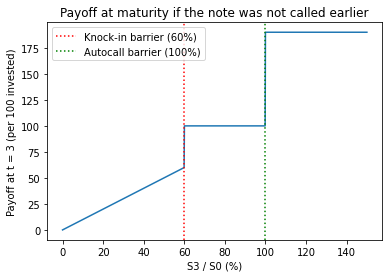

In [18]:
# Payoff diagram at maturity (for a note that was not called earlier)
perf = np.linspace(0, 1.5, 1000)        # S3 / S0 from 0% to 150%
payoff_diag = np.where(perf >= AC/S0, notional*(1 + 3*c),
              np.where(perf >= KI/S0, notional, notional*perf))

plt.plot(perf*100, payoff_diag)
plt.axvline(KI/S0*100, color='red', linestyle='dotted', label='Knock-in barrier (60%)')
plt.axvline(AC/S0*100, color='green', linestyle='dotted', label='Autocall barrier (100%)')
plt.xlabel("S3 / S0 (%)")
plt.ylabel("Payoff at t = 3 (per 100 invested)")
plt.title("Payoff at maturity if the note was not called earlier")
plt.legend()
plt.show()

## Risk for the investor under P

In this part I carry out a risk analysis of the note. Using Monte Carlo simulations under the real-world measure $P$, we look at the distribution of the investor's payoffs/losses. For the risk analysis I simulate the same paths (same random numbers $Z$) with the real-world drift $\mu$ instead of $r$. The loss on a path is 100 minus the discounted cash flow, so a negative loss is a gain. I report the call probabilities, the probability of a knock-in, the expected life of the note, and the 95% VaR and ES. Everything is done twice, once with the assumed $\mu$ and once with the historical $\mu$. The price does not depend on $\mu$, but the risk numbers do, and quite strongly.


mu = 0.09809999999999999
P(called at t=1): 0.470464
P(called at t=2): 0.118974
P(reaches maturity): 0.410562
P(knock-in, capital loss): 0.248285
Expected life (years): 1.9400979999999999
VaR (95%): 81.09038794642954
ES (95%): 86.45465920263831

mu = 0.31951882012241917
P(called at t=1): 0.641844
P(called at t=2): 0.141831
P(reaches maturity): 0.216325
P(knock-in, capital loss): 0.082158
Expected life (years): 1.574481
VaR (95%): 60.83902102509648
ES (95%): 72.58406406980588


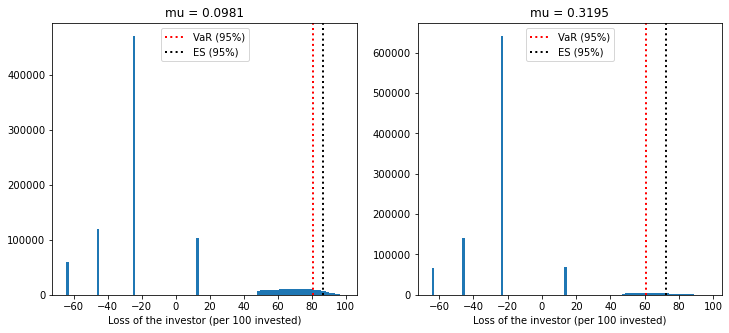

In [19]:
confidence = 0.95

# One figure with two histograms next to each other (left: assumed mu, right: historical mu)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, mu_val in enumerate([mu, mu_hist]):

    # Stock under P (same random numbers Z, only the drift changes)
    log_steps_P = (mu_val - q - 0.5*sig**2)*dt + sig*np.sqrt(dt)*Z
    S_P = S0*np.exp(np.cumsum(log_steps_P, axis=1))

    S1_P = S_P[:, 0]
    S2_P = S_P[:, 1]
    S3_P = S_P[:, 2]

    # Which paths redeem at t = 1, at t = 2, or survive to t = 3
    called_1_P = S1_P >= AC
    called_2_P = (~called_1_P) & (S2_P >= AC)
    alive_3_P = (~called_1_P) & (~called_2_P)

    # Payoff at maturity (only used for the paths that survive to t = 3)
    payoff_3_P = np.where(S3_P >= AC, notional*(1 + 3*c),
                 np.where(S3_P >= KI, notional, notional*S3_P/S0))

    # Each cash flow is discounted from the date it is paid (in today's money)
    PV_P = (called_1_P * np.exp(-r*1) * notional*(1 + c) + called_2_P * np.exp(-r*2) * notional*(1 + 2*c) + alive_3_P * np.exp(-r*3) * payoff_3_P)

    # Redemption probabilities
    p_call_1 = np.mean(called_1_P)
    p_call_2 = np.mean(called_2_P)
    p_mat = np.mean(alive_3_P)
    p_ki = np.mean(alive_3_P & (S3_P < KI))

    # Expected life of the note (in years)
    exp_life = 1*p_call_1 + 2*p_call_2 + 3*p_mat

    # VaR and ES of the investor's loss
    # The investor pays the notional (100); the loss is what they paid
    # minus what they get back, in today's money. Positive = loss.
    loss = np.sort(notional - PV_P)
    i_var = int(confidence*N)
    VaR = loss[i_var]
    ES = np.mean(loss[i_var:])

    print()
    print("mu =", mu_val)
    print("P(called at t=1):", p_call_1)
    print("P(called at t=2):", p_call_2)
    print("P(reaches maturity):", p_mat)
    print("P(knock-in, capital loss):", p_ki)
    print("Expected life (years):", exp_life)
    print("VaR (95%):", VaR)
    print("ES (95%):", ES)

    # Histogram of the investor's loss
    axes[i].hist(loss, bins=100)
    axes[i].axvline(VaR, color='red', linestyle='dotted', linewidth=2, label='VaR (95%)')
    axes[i].axvline(ES, color='black', linestyle='dotted', linewidth=2, label='ES (95%)')
    axes[i].set_xlabel("Loss of the investor (per 100 invested)")
    axes[i].set_title("mu = " + str(round(mu_val, 4)))
    axes[i].legend()

plt.show()

## Conclusion on the histograms

The histograms look as expected. Each one has four spikes, which come from the fixed payments of the note. The three spikes on the negative side are gains. They correspond to the stock being at or above $S_0$ on one of the observation dates, in which case the note pays 130, 160 or 190. The single spike on the positive side, at a loss of about 13, is the case where the stock ends between 60% and 100% of $S_0$. The investor gets the 100 back but nothing more, and once discounted this is worth less than the 100 paid at the start, so the investment did not pay off.

The spread-out part on the right of each histogram, between roughly 48 and 100, comes from the paths where the stock ends below the knock-in barrier and the put becomes active. These are by far the largest losses. The empty gap between 13 and 48 is the jump in the payoff at the 60% barrier. Since the probability of a knock-in is higher than 5%, both the VaR and the ES fall inside this part of the distribution.

The two histograms have the same shape, because the product is the same and only the drift changes. The one on the right shows smaller losses. With the higher $\mu$, more simulated paths end up above $S_0$, so the note is called early more often and fewer paths reach the knock-in region. As a result, both the VaR and the ES are lower. The results agree with the intuition behind the product, and the simulation confirms it.

## Limitations

- Volatility is constant. It would be better to use implied volatilities from Expedia's options.
- GBM has no jumps, while Expedia regularly moves sharply around earnings.
- The interest rate and dividend yield are constant, and the note is treated as risk-free debt. In reality the investor is also exposed to the credit risk of the issuing bank.